In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error

In [8]:
data = pd.read_csv('time.csv')

#беру 2 столбец с данными
y = data.iloc[:, 1].values
#шкала времени(ось X)
t = np.arange(len(y))

Линейная: 63.87009615384615
Экспоненциальная: 132.005143752115
Логистическая: 46.63924896833415


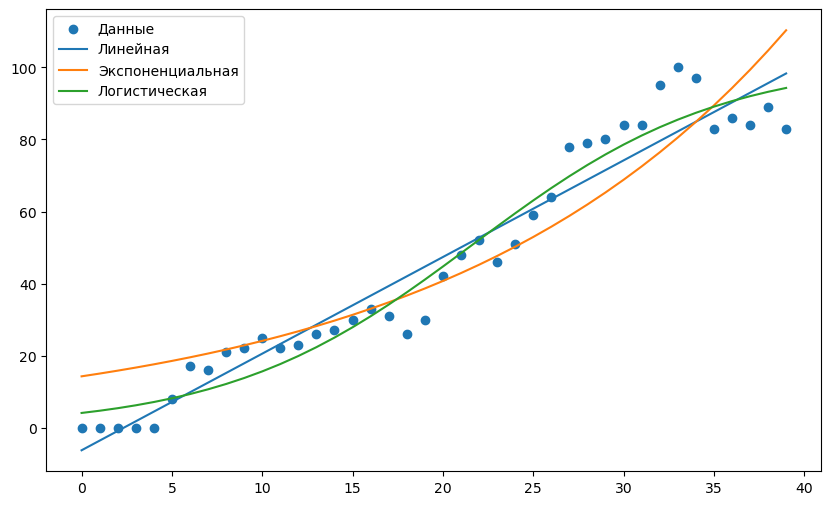

In [22]:
def linear(t, k, b):
    return k*t + b
def exp(t, a, r):
    return a * np.exp(r*t)
def log(t, K, r,t0):
    return K/(1 + np.exp(-r*(t - t0)))

#Подбираем параметры
param_lin, _ = curve_fit(linear, t, y)

param_exp, _ = curve_fit(exp, t, y, maxfev = 10000)

param_log, _ = curve_fit(log, t, y, p0=[100, 0.2, 20], maxfev = 10000)

#считаем значения моделей
y_lin = linear(t, *param_lin)
y_exp = exp(t, *param_exp)
y_log = log(t, *param_log)

#считаем ошибки
mse_lin = mean_squared_error(y, y_lin)
mse_exp = mean_squared_error(y, y_exp)
mse_log = mean_squared_error(y, y_log)

print("Линейная:", mse_lin)
print("Экспоненциальная:", mse_exp)
print("Логистическая:", mse_log)

#
plt.figure(figsize = (10, 6))

plt.scatter(t, y, label = "Данные")
plt.plot(t, y_lin, label = "Линейная")
plt.plot(t, y_exp, label = "Экспоненциальная")
plt.plot(t, y_log, label = "Логистическая")
plt.legend()

plt.show()